# Domain Adaptation with Hypernetworks

This notebook demonstrates domain adaptation via the mixture-of-hypotheses view of hypernetworks:

1. **Part 1**: Train a hypernetwork on a **combination of 3 polynomials**—data sampled from 3 unique distributions (overlapping in x, equal contribution). Each point comes from one of f₁, f₂, or f₃. With **pz frozen**, the learned $\phi$ maps different $z$ to different functions—the ensemble should contain approximations to all three polynomials.

2. **Part 2**: **Freeze $\phi$** and **unfreeze pz**, then retrain on a smaller dataset containing only one polynomial. By optimizing the distribution over $z$, the model should identify and concentrate on the correct underlying hypothesis.

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from hnet.models.HyperNet import HyperNet
from hnet.models.MLP import MLP
from hnet.synth import utils
from hnet.train.hnet import EnergyDistanceLoss

%load_ext autoreload
%autoreload 2

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using cuda


## Part 1: Combination of 3 Polynomials

Create a 1D dataset by **sampling from 3 unique distributions** (one per polynomial). Each data point $(x, y)$ comes from exactly one of f₁, f₂, or f₃:

- Sample $x \sim \text{Uniform}(0, 1)$
- Sample $k \sim \text{Categorical}(1/3, 1/3, 1/3)$ to pick polynomial $k$
- $y = f_k(x) + \epsilon$

The polynomials overlap in x-space, so the scatter looks like overlapping curves. The hypernetwork must learn a distribution over functions that can represent all three.

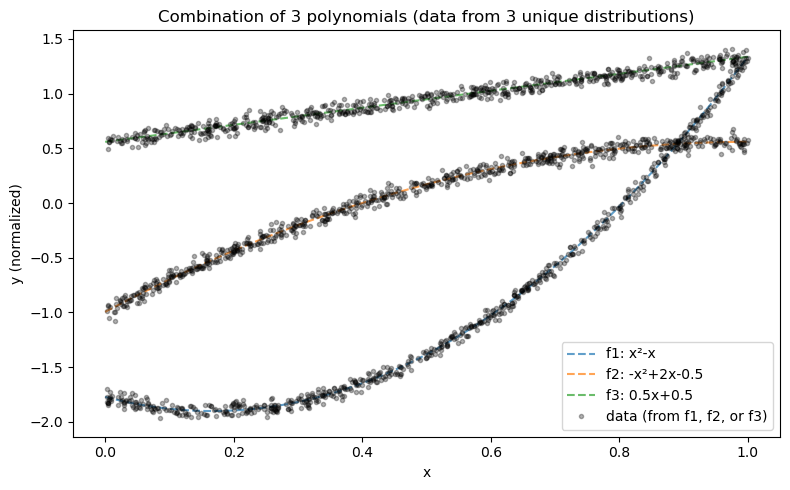

In [45]:
def poly1(x):
    """Quadratic: x^2 - x"""
    return 3*x**2 - x - 1

def poly2(x):
    """Quadratic: -x^2 + 2x - 0.5"""
    return -x**2 + 2*x - 0.5

def poly3(x):
    """Linear-ish: 0.5x + 0.5"""
    return 0.5*x + 0.5

def combination_of_polynomials(N, scale=0.05, seed=42):
    """Sample from 3 unique polynomial distributions (equal contribution).
    Each point (x,y) comes from exactly one of f1, f2, f3. Returns x, y, and true curves."""
    torch.manual_seed(seed)
    x = torch.rand(N)
    k = torch.randint(0, 3, (N,))  # which polynomial for each point
    f1, f2, f3 = poly1(x), poly2(x), poly3(x)
    y = torch.where(k == 0, f1, torch.where(k == 1, f2, f3)) + scale * torch.randn(N)
    # For plotting: true curves over a dense x grid
    x_grid = torch.linspace(0, 1, 500)
    y_true_f1 = poly1(x_grid)
    y_true_f2 = poly2(x_grid)
    y_true_f3 = poly3(x_grid)
    return x, y, x_grid, y_true_f1, y_true_f2, y_true_f3

# Generate data from 3 unique distributions
N = 2000
x, y, x_grid, y_true_f1, y_true_f2, y_true_f3 = combination_of_polynomials(N, scale=0.025)
x = x.unsqueeze(1)
y = y.unsqueeze(1)

# Normalize for stable training
y_mu, y_std = y.mean().item(), y.std().item()
y = (y - y_mu) / (y_std + 1e-8)
y_true_f1 = (y_true_f1 - y_mu) / (y_std + 1e-8)
y_true_f2 = (y_true_f2 - y_mu) / (y_std + 1e-8)
y_true_f3 = (y_true_f3 - y_mu) / (y_std + 1e-8)

# For plot1d/training: evaluate reference curves at data x
y_true_at_x = (poly1(x.squeeze()) + poly2(x.squeeze()) + poly3(x.squeeze())) / 3
y_true_at_x = (y_true_at_x - y_mu) / (y_std + 1e-8)
y_true = y_true_at_x.unsqueeze(1)
true_lcb = (y_true_at_x - 0.3).unsqueeze(1)
true_ucb = (y_true_at_x + 0.3).unsqueeze(1)

# Dense grid for smooth prediction plots
x_plot = torch.linspace(0, 1, 500).unsqueeze(1)

# Plot: individual polynomials + scattered data from all 3
fig, ax = plt.subplots(figsize=(8, 5))
xx = x_grid.numpy()
ax.plot(xx, y_true_f1.numpy(), '--', alpha=0.7, label='f1: x²-x')
ax.plot(xx, y_true_f2.numpy(), '--', alpha=0.7, label='f2: -x²+2x-0.5')
ax.plot(xx, y_true_f3.numpy(), '--', alpha=0.7, label='f3: 0.5x+0.5')
ax.plot(x.squeeze().numpy(), y.squeeze().numpy(), 'k.', alpha=0.3, label='data (from f1, f2, or f3)')
ax.set_xlabel('x')
ax.set_ylabel('y (normalized)')
ax.legend()
ax.set_title('Combination of 3 polynomials (data from 3 unique distributions)')
plt.tight_layout()
plt.show()

### Train hypernetwork with pz frozen

We freeze the normalizing flow (pz) so the prior over $z$ is fixed. Only $\phi$ is trained. The ensemble of functions induced by sampling $z$ should approximate all three polynomials.

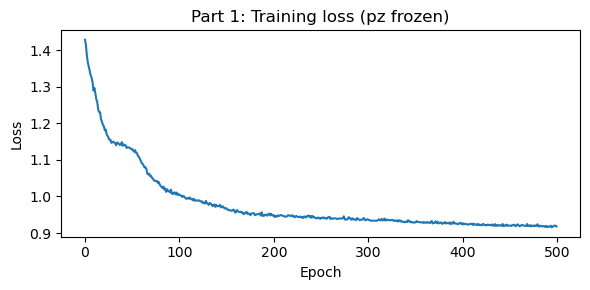

In [48]:
# Build model with learn_pz=True (needed for Part 2). We freeze the flow in Part 1.
mlp = MLP(in_channels=1, out_channels=1, hidden_channels=64, layers=3, nonlin='elu', dropout=0., norm='layer')

hnet = HyperNet(
    mlp,
    stochastic_channels=32,
    width=64,
    dropout=0., norm='none', bias=False,
    pz='normal',
    learn_pz=True,  # flow exists for Part 2; we freeze it now
    nvp_kwargs={'hidden_dim': 32, 'num_layers': 4, 'nonlin': 'elu', 'mask_type': 'alternating'},
).to(device)

# Freeze pz (normalizing flow) for Part 1
for p in hnet.normalizing_flow.parameters():
    p.requires_grad = False

# Train only f_phi
optim = torch.optim.Adam(filter(lambda p: p.requires_grad, hnet.parameters()), lr=1e-4)
crit = EnergyDistanceLoss()

x_dev = x.to(device)
y_dev = y.to(device)
batch_size, num_epochs, nsamples = 512, 500, 500
losses = []

for i in range(num_epochs):
    batch_loss = []
    for idx in torch.split(torch.randperm(x.size(0)), batch_size):
        optim.zero_grad()
        yhat = hnet(x_dev[idx], samples=nsamples)
        loss = crit(yhat, y_dev[idx])
        loss.backward()
        optim.step()
        batch_loss.append(loss.item())
    losses.append(np.mean(batch_loss))
    print(f'Epoch {i}/{num_epochs}  loss: {losses[-1]:.4f}', end='\r')

hnet = hnet.cpu()
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Part 1: Training loss (pz frozen)')
plt.tight_layout()
plt.show()

### Plot resulting functions

Sample many functions from the trained hypernetwork. The ensemble should span the mixture and approximate the individual polynomial modes.

(NOTE: ignore the red "true" data, this is a average and not useful)

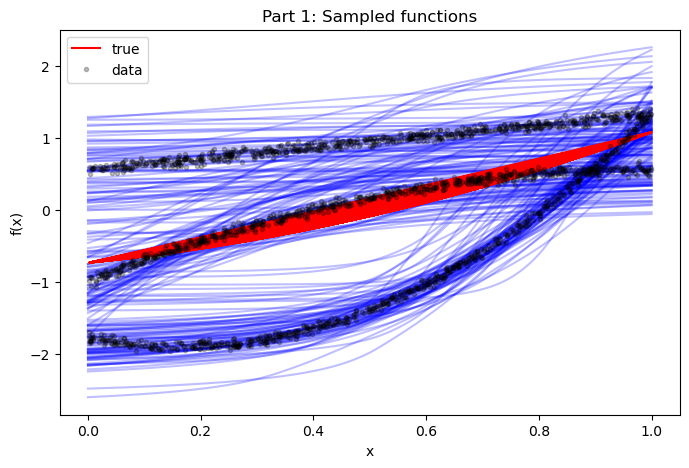

In [49]:
hnet.eval()
with torch.no_grad():
    yhat = hnet(x_plot, samples=200)

utils.plot1d(x.squeeze(), y.squeeze(), y_true.squeeze(), true_lcb.squeeze(), true_ucb.squeeze(),
             x2=x_plot.squeeze(), yhat=yhat, title='Part 1: Sampled functions', plot_ci=False)

## Part 2: Domain adaptation via pz

Now we have a target domain: **only polynomial 1** (e.g. $f_1(x) = x^2 - x$). The mixture-trained $\phi$ already contains hypotheses for all three polynomials. By **freezing $\phi$** and **optimizing pz**, we adapt the model to concentrate probability mass on the $z$ that corresponds to the correct hypothesis.

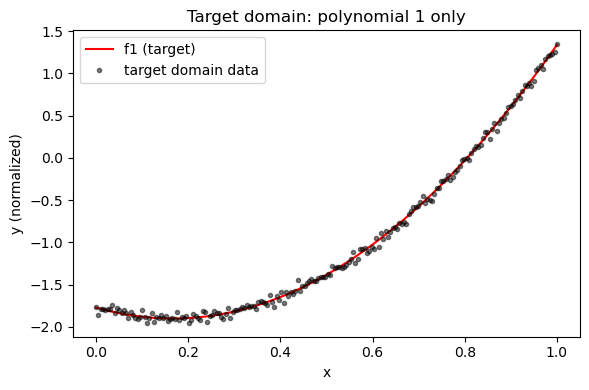

In [50]:
# Target domain: data from polynomial 1 only (smaller dataset)
N_adapt = 200  # smaller dataset
x_adapt = torch.linspace(0, 1, N_adapt).unsqueeze(1)
y_adapt = (poly1(x_adapt.squeeze()) + 0.025 * torch.randn_like(x_adapt.squeeze())).unsqueeze(1)
y_adapt = (y_adapt - y_mu) / (y_std + 1e-8)  # same normalization as Part 1

# Plot target domain
fig, ax = plt.subplots(figsize=(6, 4))
xx = x_adapt.squeeze().numpy()
ax.plot(xx, (poly1(x_adapt.squeeze()) - y_mu) / (y_std + 1e-8), 'r-', label='f1 (target)')
ax.plot(xx, y_adapt.squeeze().numpy(), 'k.', alpha=0.5, label='target domain data')
ax.set_xlabel('x')
ax.set_ylabel('y (normalized)')
ax.legend()
ax.set_title('Target domain: polynomial 1 only')
plt.tight_layout()
plt.show()

### Freeze $\phi$, unfreeze pz, retrain

Adapt epoch 100, loss: 0.7723
Adapt epoch 200, loss: 0.3680
Adapt epoch 300, loss: 0.1565
Adapt epoch 400, loss: 0.1009
Adapt epoch 500, loss: 0.0884
Adapt epoch 600, loss: 0.0982
Adapt epoch 700, loss: 0.0887
Adapt epoch 800, loss: 0.0876
Adapt epoch 900, loss: 0.0793
Adapt epoch 1000, loss: 0.0786


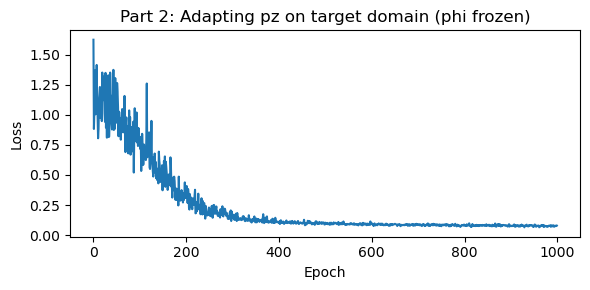

In [51]:
# Freeze f_phi (all base network mappings)
for p in hnet.f_phi.parameters():
    p.requires_grad = False

# Unfreeze normalizing flow (pz)
for p in hnet.normalizing_flow.parameters():
    p.requires_grad = True

# Retrain only pz on target domain
optim_adapt = torch.optim.AdamW(hnet.normalizing_flow.parameters(), lr=1e-4, weight_decay=1e-6)
hnet = hnet.to(device)
x_adapt_dev = x_adapt.to(device)
y_adapt_dev = y_adapt.to(device)

losses_adapt = []
for i in range(500):
    optim_adapt.zero_grad()
    idx = torch.randint(0, len(x_adapt), (min(64, len(x_adapt)),))
    yhat = hnet(x_adapt_dev[idx], samples=100)
    loss = crit(yhat, y_adapt_dev[idx])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(hnet.parameters(), 1.0)
    optim_adapt.step()
    losses_adapt.append(loss.item())
    if (i + 1) % 100 == 0:
        print(f'Adapt epoch {i+1}, loss: {loss.item():.4f}')

hnet = hnet.cpu()
plt.figure(figsize=(6, 3))
plt.plot(losses_adapt)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Part 2: Adapting pz on target domain (phi frozen)')
plt.tight_layout()
plt.show()

### Plot after adaptation

After optimizing pz on the target domain, the sampled functions should concentrate around the correct hypothesis (polynomial 1). The mixture-trained $\phi$ contained the right function; pz learned to select it.

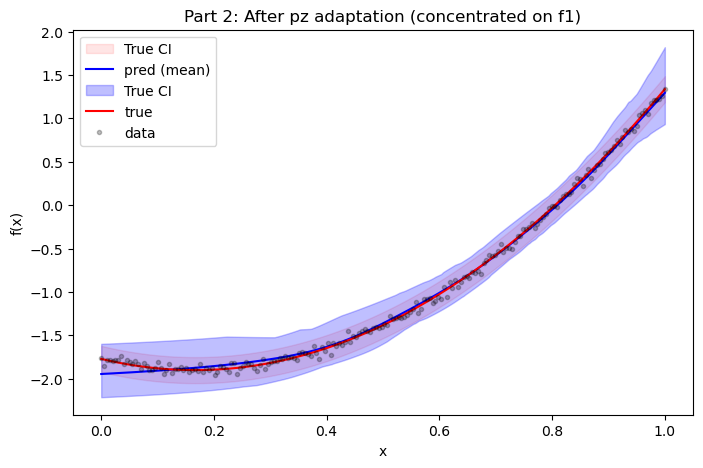

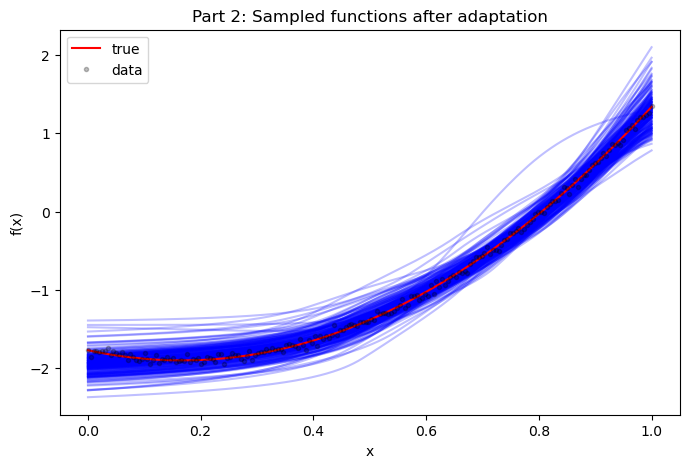

In [52]:
# True f1 at adaptation points (normalized)
y_true_f1_adapt = (poly1(x_adapt.squeeze()) - y_mu) / (y_std + 1e-8)

hnet.eval()
with torch.no_grad():
    yhat_adapt = hnet(x_plot, samples=200)

# Plot: adaptation data + predictions over full x grid
utils.plot1d(x_adapt.squeeze(), y_adapt.squeeze(),
             y_true_f1_adapt, y_true_f1_adapt - 0.15, y_true_f1_adapt + 0.15,
             x2=x_plot.squeeze(), yhat=yhat_adapt,
             title='Part 2: After pz adaptation (concentrated on f1)', plot_ci=True)
utils.plot1d(x_adapt.squeeze(), y_adapt.squeeze(),
             y_true_f1_adapt, y_true_f1_adapt - 0.15, y_true_f1_adapt + 0.15,
             x2=x_plot.squeeze(), yhat=yhat_adapt,
             title='Part 2: Sampled functions after adaptation', plot_ci=False)